In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, \
    load_gbs_gesis, load_gbs_allensbach, load_folktables_employment_data
from utils.metrics import train_feature_weighted_random_forest
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import  sample_with_test_set
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import  mrs
from weighting_methods.maximum_representative_subsampling import mrs_step
from utils.metrics import compute_classification_metrics_random_forest, \
    compute_classification_metrics_tree, compute_classification_metrics_feature_weights, compute_feature_weights_with_temperature
from utils.metrics import compute_test_metrics_fw_mrs, train_random_forest_classifier_mrs, compute_test_metrics_mrs


2024-08-15 15:34:44.897449: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-15 15:34:45.856751: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
df, columns, target = load_breast_cancer_data()
df[columns] = StandardScaler().fit_transform(df[columns])
# N = df[df["label"] == 1]
# R = df[df["label"] == 0]
N, R, T = sample_with_test_set(
           "mean_difference",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           test_fraction=0.1,
           columns=columns,
       )
dropped_N = N.copy().reset_index(drop=True)

In [3]:
# _, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)
drop_ids, feature_importance_cv = mrs(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)

<Axes: >

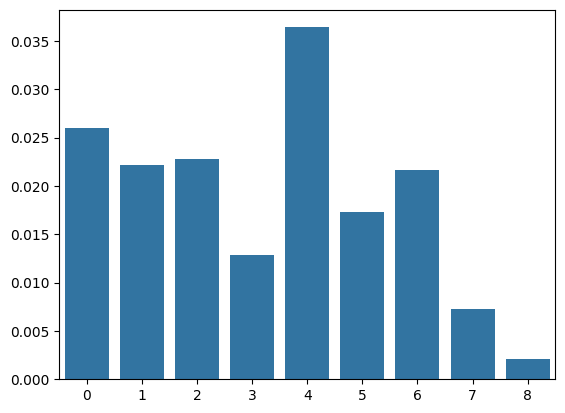

In [4]:
feature_weights = compute_feature_weights_with_temperature(0.01, feature_importance_cv)
sns.barplot(feature_importance_cv)

In [5]:
seed = 5
max_features = "sqrt"
sample_weights = np.ones(len(N)) / len(N)
n_estimators=100

feature_weights_list = []
# budgets = [None, 0.1, 0.01, 0.005, 0.001]
budgets = [None, 0.1, 0.05, 0.01, 0.005]
for budget in budgets:
    feature_weights = compute_feature_weights_with_temperature(budget, feature_importance_cv)
    feature_weights_list.append(feature_weights)

In [6]:
for i, budget in enumerate(budgets):
   auroc = compute_test_metrics_fw_mrs(
       dropped_N,
       R,
       columns,
       random_state=seed,
       feature_weights=feature_weights_list[i],
       method=train_feature_weighted_random_forest,
       class_weight="balanced",
       max_features="sqrt",
       splitter="feature_weighted_best",
       n_splits_test=10,
       n_estimators=200,
       draw_with_feature_weights=True,
   )
   print(f"{budget}: {auroc}")

None: 0.6222782258064516


None: 0.6195240704345581
0.1: 0.6181144636015325\
0.05: 0.617988343209656\
0.01: 0.6095037358803328\
0.005: 0.5953715234351736\
0.001: 0.5382615351974273\

In [ ]:
for i,budget in enumerate(budgets):
    feature_weights = feature_weights_list[i]
    auroc, auprc, _, _, _ = compute_classification_metrics_random_forest(
            N,
            R,
            R,
            columns,
            sample_weights,
            feature_weights,
            target,
            random_state=seed,
            n_splits=10,
            splitter="feature_weighted_best",
            n_estimators=200,
            draw_with_feature_weights=True,
            compute_feature_importance=False
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

None Auroc: 0.9897685185185185\
None AUPRC: 0.9952434438490332

0.05 Auroc: 0.9884722222222222\
0.05 AUPRC: 0.9948154401835849

0.01 Auroc: 0.987962962962963\
0.01 AUPRC: 0.9943947194109652

0.005 Auroc: 0.9855324074074073\
0.005 AUPRC: 0.9933045518147399